Full Dataset Visualization

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import mmread
from scipy import sparse

# =====================================
# Load Data
# =====================================

DATA_DIR = "./data"
RESULTS_DIR = "./results"

genes = pd.read_csv(
    f"{DATA_DIR}/genes.tsv",
    sep="\t",
    header=None
)[0].astype(str)

barcodes = pd.read_csv(
    f"{DATA_DIR}/barcodes.tsv",
    sep="\t",
    header=None
)[0].astype(str)

counts = mmread(f"{DATA_DIR}/counts.mtx")

if not sparse.issparse(counts):
    counts = sparse.coo_matrix(counts)

counts = counts.T.tocsr()

meta = pd.read_csv(
    f"{DATA_DIR}/GSE183276_Kidney_Healthy-Injury_Cell_Atlas_scCv3_Metadata_03282022.txt",
    sep="\t",
    index_col=0,
    low_memory=False
)

# =====================================
# Create AnnData
# =====================================

adata = sc.AnnData(X=counts)

adata.var_names = genes.values
adata.obs_names = barcodes.values

common = adata.obs_names.intersection(meta.index)

adata = adata[common].copy()
adata.obs = meta.loc[common].copy()

print(adata)

AnnData object with n_obs × n_vars = 109741 × 37080
    obs: 'library', 'nCount_RNA', 'nFeature_RNA', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'Phase', 'experiment', 'experiment.short', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'condition.l3', 'patient', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sex', 'race', 'tissue_type', 'assay', 'location', 'laterality', 'snDrop_predicted_subclass', 'snDrop_prediction_score', 'clusters', 'id', 'predicted.class.score', 'predicted.class', 'predicted.subclass.l1.score', 'predicted.subclass.l1', 'predicted.subclass.l3.score', 'predicted.subclass.l3', 'sc.subclass.l2', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'tal.module', 'pt.module'


1. Cells per condition

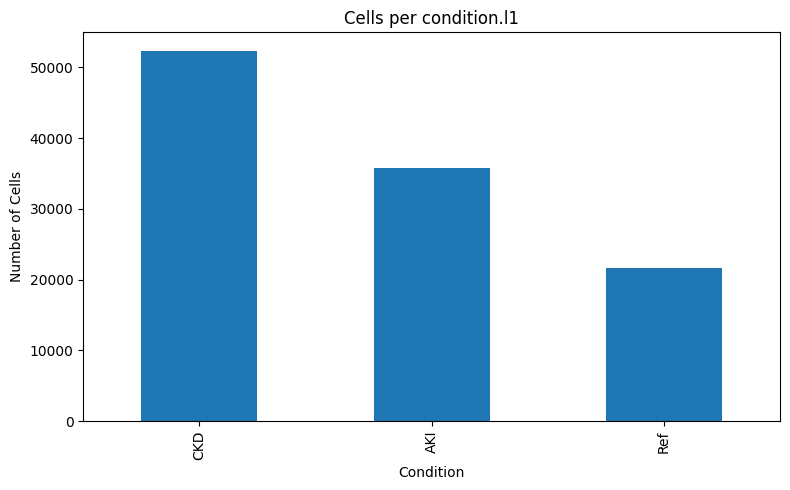

In [2]:
plt.figure(figsize=(8,5))

adata.obs["condition.l1"].value_counts().plot(kind="bar")

plt.title("Cells per condition.l1")
plt.xlabel("Condition")
plt.ylabel("Number of Cells")

plt.tight_layout()

plt.show()

2. Top Cell Types

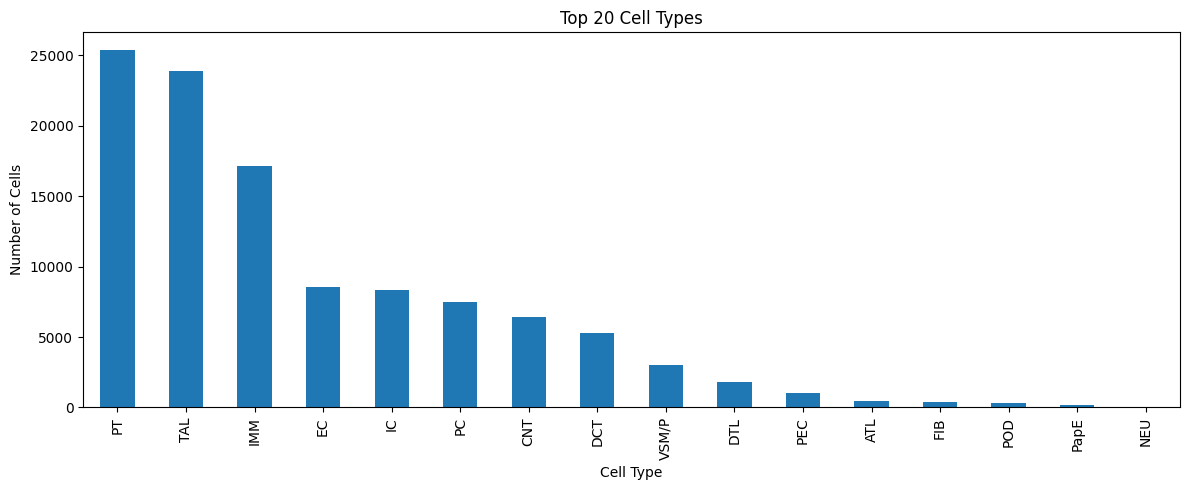

In [3]:
plt.figure(figsize=(12,5))

adata.obs["subclass.l1"].value_counts().head(20).plot(kind="bar")

plt.title("Top 20 Cell Types")
plt.xlabel("Cell Type")
plt.ylabel("Number of Cells")

plt.tight_layout()

plt.show()

3. Structure Distribution

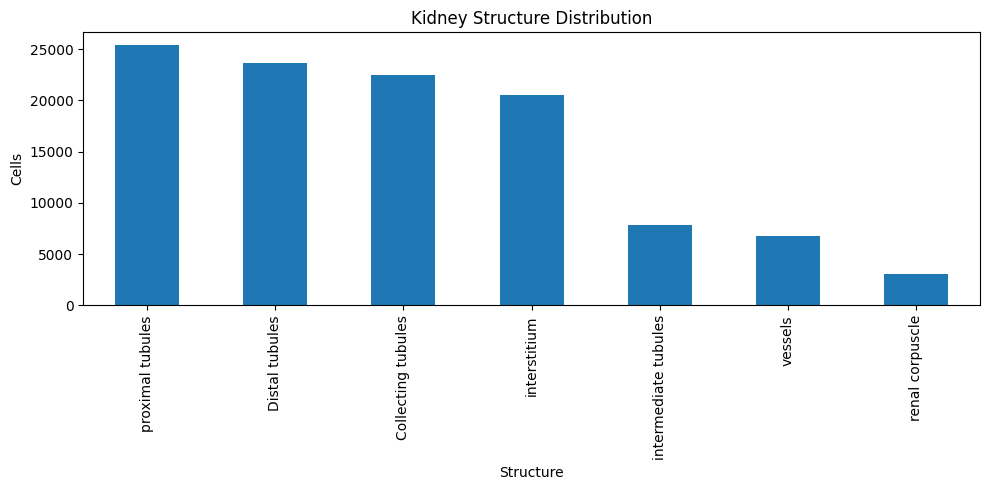

In [4]:
plt.figure(figsize=(10,5))

adata.obs["structure"].value_counts().plot(kind="bar")

plt.title("Kidney Structure Distribution")
plt.xlabel("Structure")
plt.ylabel("Cells")

plt.tight_layout()

plt.show()

4. Total RNA counts distribution

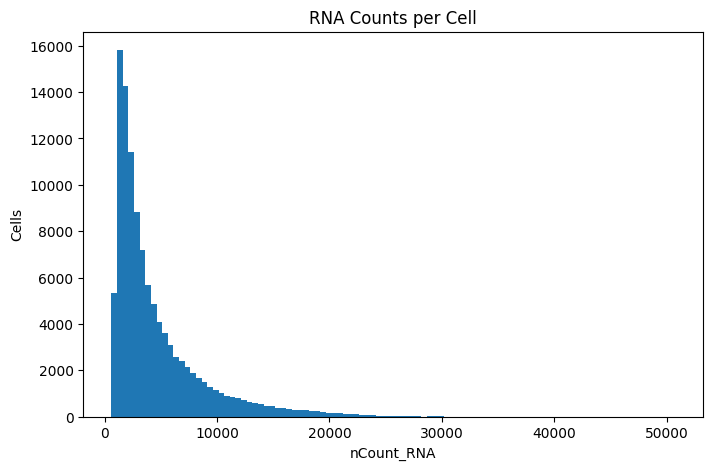

In [5]:
plt.figure(figsize=(8,5))

plt.hist(
    adata.obs["nCount_RNA"],
    bins=100
)

plt.xlabel("nCount_RNA")
plt.ylabel("Cells")

plt.title("RNA Counts per Cell")

plt.show()

5. Detected genes per cell

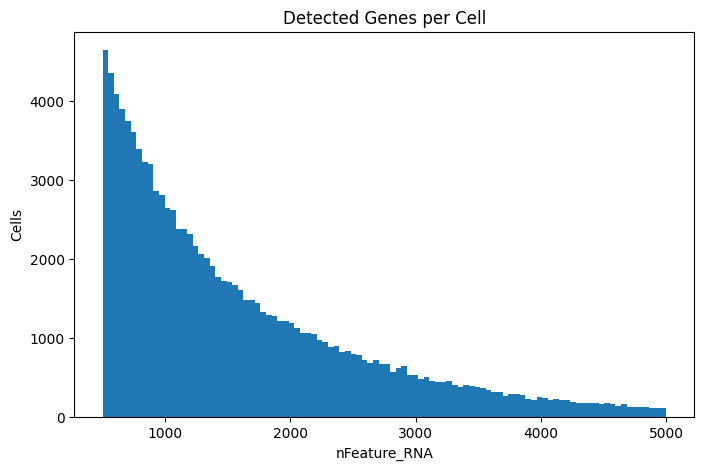

In [6]:
plt.figure(figsize=(8,5))

plt.hist(
    adata.obs["nFeature_RNA"],
    bins=100
)

plt.xlabel("nFeature_RNA")
plt.ylabel("Cells")

plt.title("Detected Genes per Cell")

plt.show()

6. Mitochondrial percentage

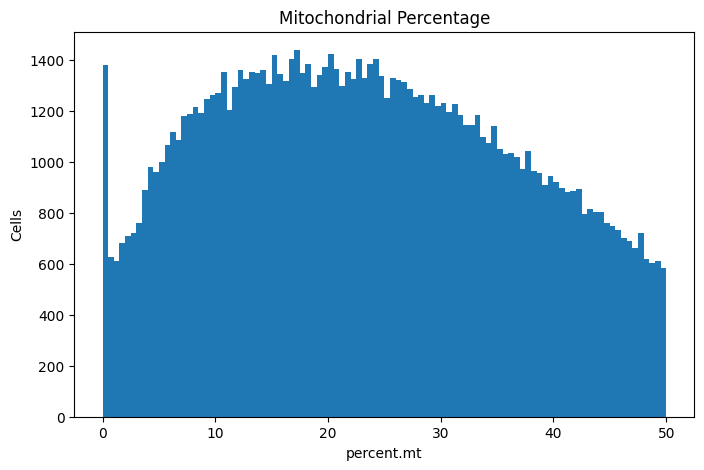

In [7]:
plt.figure(figsize=(8,5))

plt.hist(
    adata.obs["percent.mt"],
    bins=100
)

plt.xlabel("percent.mt")
plt.ylabel("Cells")

plt.title("Mitochondrial Percentage")

plt.show()

7. Scatter Plot — QC relationship

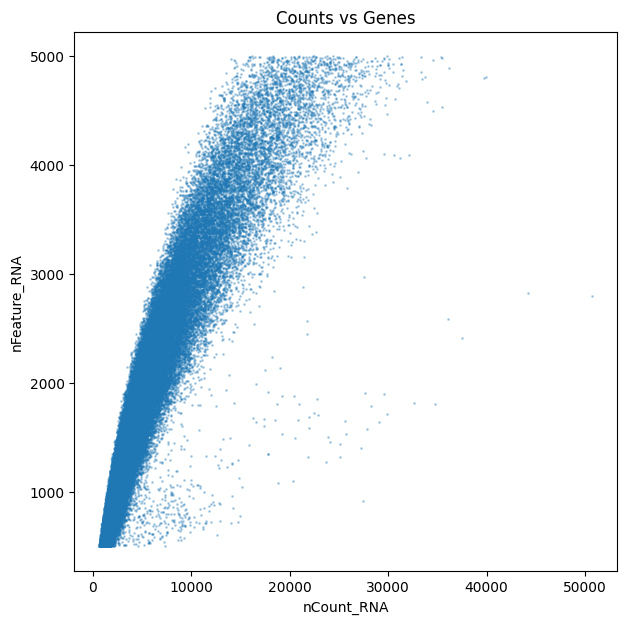

In [8]:
plt.figure(figsize=(7,7))

plt.scatter(
    adata.obs["nCount_RNA"],
    adata.obs["nFeature_RNA"],
    s=1,
    alpha=0.3
)

plt.xlabel("nCount_RNA")
plt.ylabel("nFeature_RNA")

plt.title("Counts vs Genes")

plt.show()

8. Mitochondrial vs RNA counts

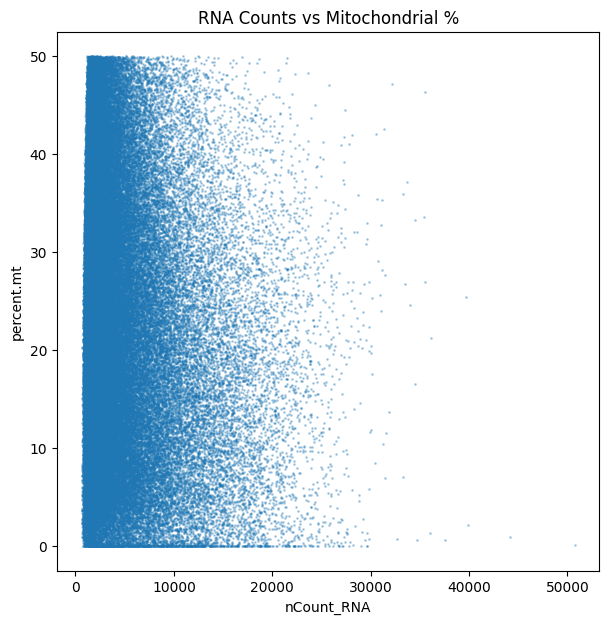

In [9]:
plt.figure(figsize=(7,7))

plt.scatter(
    adata.obs["nCount_RNA"],
    adata.obs["percent.mt"],
    s=1,
    alpha=0.3
)

plt.xlabel("nCount_RNA")
plt.ylabel("percent.mt")

plt.title("RNA Counts vs Mitochondrial %")

plt.show()

9. Top Expressed Genes

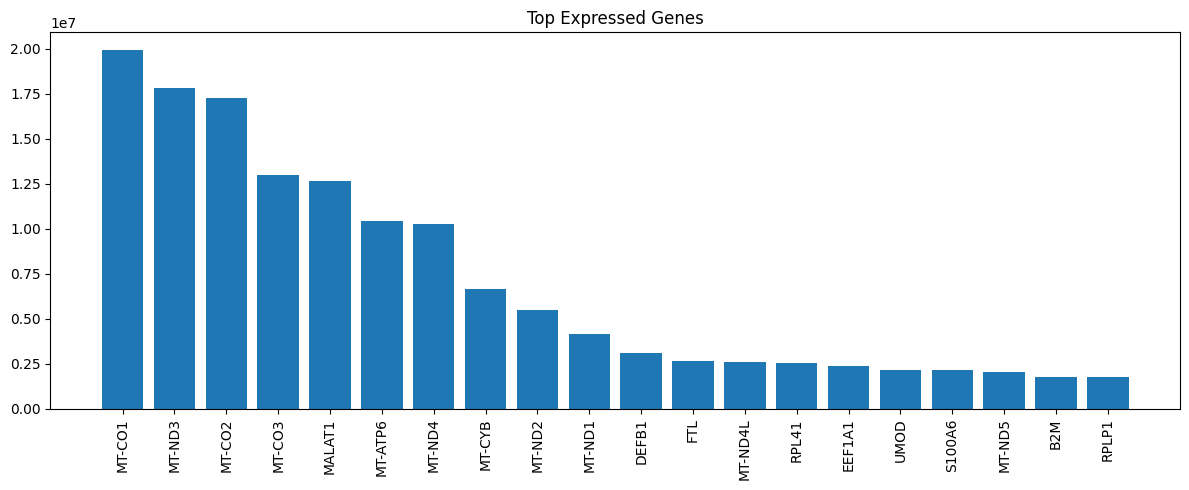

In [10]:
gene_sums = np.asarray(adata.X.sum(axis=0)).ravel()

gene_df = pd.DataFrame({
    "gene": adata.var_names,
    "total_expression": gene_sums
})

gene_df = gene_df.sort_values(
    "total_expression",
    ascending=False
)

top20 = gene_df.head(20)

plt.figure(figsize=(12,5))

plt.bar(
    top20["gene"],
    top20["total_expression"]
)

plt.xticks(rotation=90)

plt.title("Top Expressed Genes")

plt.tight_layout()

plt.show()

10. Sparsity Visualization

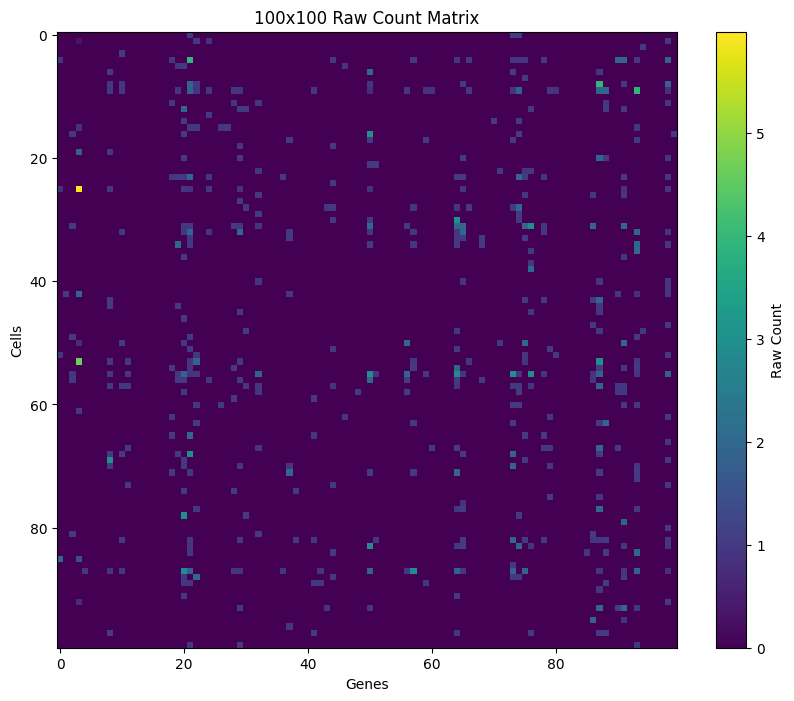

In [11]:
small = adata.X[:100, :100].toarray()

plt.figure(figsize=(10,8))

plt.imshow(
    small,
    aspect="auto"
)

plt.colorbar(label="Raw Count")

plt.xlabel("Genes")
plt.ylabel("Cells")

plt.title("100x100 Raw Count Matrix")

plt.show()

11. Cell Type Pie Chart

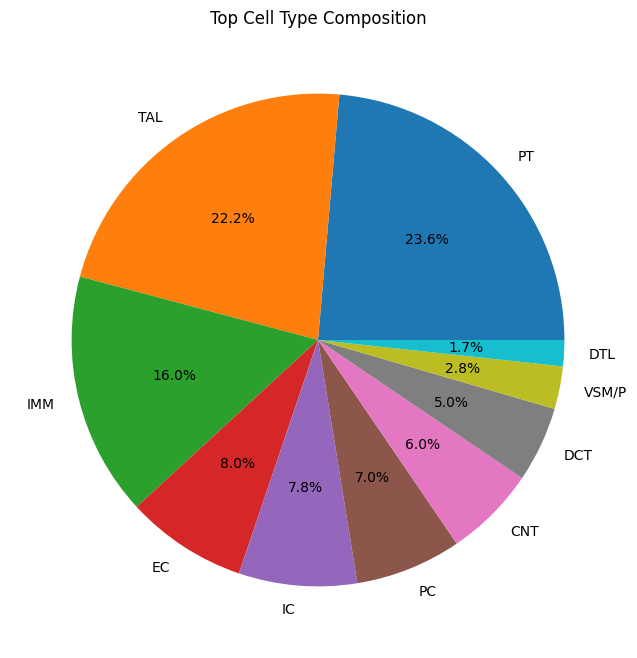

In [12]:
top_celltypes = adata.obs["subclass.l1"].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top_celltypes.values,
    labels=top_celltypes.index,
    autopct="%1.1f%%"
)

plt.title("Top Cell Type Composition")

plt.show()

12. Disease vs Cell Types

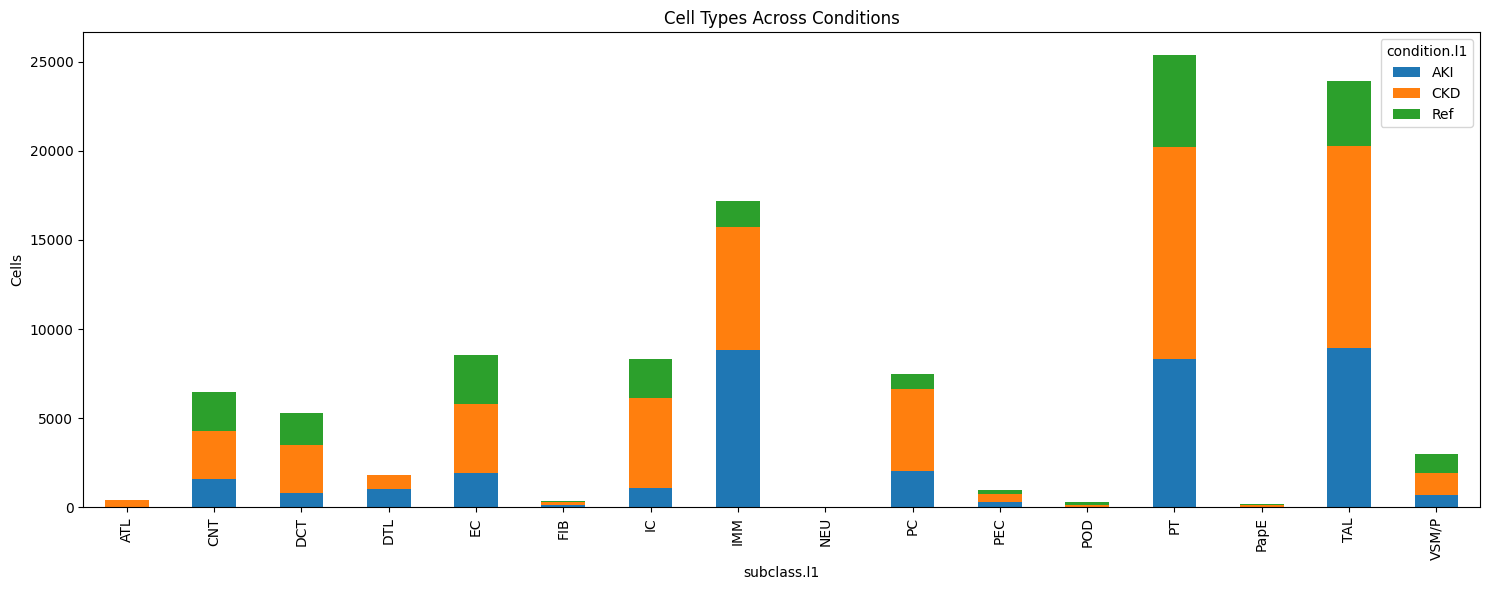

In [13]:
cross = pd.crosstab(
    adata.obs["condition.l1"],
    adata.obs["subclass.l1"]
)

cross.T.head(20).plot(
    kind="bar",
    stacked=True,
    figsize=(15,6)
)

plt.title("Cell Types Across Conditions")

plt.ylabel("Cells")

plt.tight_layout()

plt.show()

In [ ]:
13. Print important summary

In [14]:
print("\n===== Dataset Summary =====")

print("Cells:", adata.n_obs)
print("Genes:", adata.n_vars)

print("\nCondition counts:")
print(adata.obs["condition.l1"].value_counts())

print("\nCell type counts:")
print(adata.obs["subclass.l1"].value_counts().head(20))

print("\nStructures:")
print(adata.obs["structure"].value_counts())

print("\nQC Summary:")
print(
    adata.obs[
        ["nCount_RNA", "nFeature_RNA", "percent.mt"]
    ].describe()
)


===== Dataset Summary =====
Cells: 109741
Genes: 37080

Condition counts:
condition.l1
CKD    52314
AKI    35777
Ref    21650
Name: count, dtype: int64

Cell type counts:
subclass.l1
PT       25373
TAL      23894
IMM      17176
EC        8550
IC        8334
PC        7483
CNT       6459
DCT       5324
VSM/P     3011
DTL       1836
PEC       1005
ATL        431
FIB        372
POD        284
PapE       202
NEU          7
Name: count, dtype: int64

Structures:
structure
proximal tubules        25373
Distal tubules          23629
interstitium            20500
intermediate tubules     7856
vessels                  6816
renal corpuscle          3089
Name: count, dtype: int64

QC Summary:
          nCount_RNA   nFeature_RNA     percent.mt
count  109741.000000  109741.000000  109741.000000
mean     4617.207004    1585.355646      23.620371
std      4189.690491     987.924072      13.093615
min       616.879301     501.000000       0.000000
25%      1825.810000     811.000000      12.901130
50